# Black-Litterman — Market Equilibrium + Investor Views

Black-Litterman solves the core problem of MPT: sensitivity to input assumptions.
Instead of feeding raw historical returns into the optimizer, it starts from a stable
anchor — what the market collectively implies returns should be — and then adjusts
that anchor based on forward-looking investor views.

The result is a set of posterior expected returns that blend two sources of information:
1. **Market equilibrium** — implied by Global Market Portfolio weights (State Street, 2025)
2. **Investor views** — forward-looking return estimates (State Street GMP 2025, Figure 9)

Those posterior returns feed into a standard mean-variance optimizer, producing
more stable and diversified portfolios than naive MPT.

**Market cap weights source**: State Street Investment Management (2025).
*Global Market Portfolio 2025: A Portfolio of Everything.* Figure 3, Q1 2025.
Weights normalized to the six-asset universe.

**Views source**: State Street Investment Management (2025). Figure 9 return forecasts.
Equity: 7.5% | Gov. Bonds: 4.3% | IG Credit: 4.9% | Infl. Linked: 3.9% | Gold: 2.5%

Assets: `BND, GLD, TIP, TLT, VEU, VGT`

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco
from pathlib import Path
import numpy as np
import json

# Load market configuration
with open("../../markets.json", "r") as f:
    config = json.load(f)

name = "primary_total_market"
market_name        = list(config["markets"].keys())[0]
BASE = Path("../../data")
print(BASE)
price_file = BASE / f"{name}_prices_monthly.csv"
returns_file = BASE / f"{name}_returns_monthly.csv"

INITIAL_INVESTMENT = config["initial_investment"]
MONTHLY_INVESTMENT = config["monthly_investment"]

..\..\data


In [17]:

# ── Key parameters ─────────────────────────────────────────────────────────────
LOOKBACK            = 36    # months of past data used in rolling covariance
REBALANCE_THRESHOLD = 0.05  # only rebalance if any weight drifts more than 5%
RISK_AVERSION       = 3.0   # market risk aversion coefficient (standard value)


# ── View uncertainty (tau) ────────────────────────────────────────────────────
# Tau controls how much weight to give views vs equilibrium.
# Small tau = trust the market more. Large tau = trust views more.
# 0.05 is a standard starting value in the Black-Litterman literature.
TAU = 0.05

# ── Market cap weights ────────────────────────────────────────────────────────
# Source: State Street Investment Management (2025).
# Global Market Portfolio 2025: A Portfolio of Everything. Figure 3.
# Weights normalized from GMP asset class weights to this six-asset universe.
# BND=IG Credit(9.1%), TIP=Infl.Linked(1.5%), TLT=Gov.Bonds(21.1%),
# GLD=Gold(4.5%), VEU=Intl Equity(~16%), VGT=US Tech Equity(~28%)
MARKET_CAP_WEIGHTS = {
    "BND": 0.11,
    "GLD": 0.06,
    "TIP": 0.02,
    "TLT": 0.26,
    "VEU": 0.20,
    "VGT": 0.35,
}

# ── Investor views ────────────────────────────────────────────────────────────
# Source: State Street Investment Management (2025).
# Global Market Portfolio 2025: A Portfolio of Everything. Figure 9.
# Forward-looking annualized return forecasts (1-year horizon).
INVESTOR_VIEWS = {
    "BND": 0.049,   # IG Credit: 4.9%
    "GLD": 0.025,   # Gold: 2.5%
    "TIP": 0.039,   # Inflation Linked Bonds: 3.9%
    "TLT": 0.043,   # Government Bonds: 4.3%
    "VEU": 0.075,   # Equity (international): 7.5%
    "VGT": 0.075,   # Equity (US tech): 7.5%
}

# ── Crisis periods for chart shading ─────────────────────────────────────────
CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

# ── Color palette ─────────────────────────────────────────────────────────────
PALETTE = {
    "Black-Litterman": "#E53E3E",
    "Equal Weight"   : "#028090",
    "Market Cap"     : "#6B46C1",
}

plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market           : {market_name}")
print(f"Rolling window   : {LOOKBACK} months")
print(f"Risk aversion    : {RISK_AVERSION}")
print(f"Tau              : {TAU}")
print(f"\nMarket cap weights:")
for asset, weight in MARKET_CAP_WEIGHTS.items():
    print(f"  {asset}: {weight*100:.0f}%")
print(f"\nInvestor views (State Street GMP 2025, Figure 9):")
for asset, view in INVESTOR_VIEWS.items():
    print(f"  {asset}: {view*100:.1f}%")

Market           : primary_total_market
Rolling window   : 36 months
Risk aversion    : 3.0
Tau              : 0.05

Market cap weights:
  BND: 11%
  GLD: 6%
  TIP: 2%
  TLT: 26%
  VEU: 20%
  VGT: 35%

Investor views (State Street GMP 2025, Figure 9):
  BND: 4.9%
  GLD: 2.5%
  TIP: 3.9%
  TLT: 4.3%
  VEU: 7.5%
  VGT: 7.5%


In [18]:
returns = pd.read_csv(
    BASE / f"{market_name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)
returns = returns.dropna()

assets     = list(returns.columns)
num_assets = len(assets)

# Align market cap weights and views to asset order in returns dataframe
market_cap_weight_array = np.array([MARKET_CAP_WEIGHTS[asset] for asset in assets])
investor_view_array     = np.array([INVESTOR_VIEWS[asset]     for asset in assets])

print(f"Period : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"Assets : {assets}")
print(f"Months : {len(returns)}")

Period : 2007-05-01 -> 2025-12-01
Assets : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Months : 224


In [19]:
# ── Cell 3: Rolling Risk-Free Rate ────────────────────────────────────────────
risk_free_file = BASE / "risk_free_monthly.csv"

if risk_free_file.exists():
    risk_free_data        = pd.read_csv(risk_free_file, index_col=0, parse_dates=True)
    risk_free_data        = risk_free_data.reindex(returns.index, method="ffill")
    annual_rf_series      = risk_free_data["rf_annual"]
    monthly_rf_series     = risk_free_data["rf_monthly"]
    avg_annual_risk_free  = annual_rf_series.mean()
    avg_monthly_risk_free = monthly_rf_series.mean()
    print(f"Rolling RF loaded  : {len(risk_free_data)} months")
    print(f"  Range  : {annual_rf_series.min()*100:.2f}% - {annual_rf_series.max()*100:.2f}%")
    print(f"  Average: {avg_annual_risk_free*100:.3f}% annual")
else:
    print("WARNING: risk_free_monthly.csv not found. Run main.ipynb first.")
    avg_annual_risk_free  = 0.0351
    avg_monthly_risk_free = (1 + avg_annual_risk_free) ** (1/12) - 1
    annual_rf_series      = pd.Series(avg_annual_risk_free,  index=returns.index)
    monthly_rf_series     = pd.Series(avg_monthly_risk_free, index=returns.index)

Rolling RF loaded  : 224 months
  Range  : 0.01% - 5.34%
  Average: 1.415% annual


In [20]:
# ── Cell 4: Black-Litterman Core Function ─────────────────────────────────────
# This is the mathematical heart of the model.
#
# Step 1 — Implied Equilibrium Returns:
#   Reverse-engineer what returns the market must be expecting given current
#   market cap weights and the covariance structure of returns.
#   Formula: pi = risk_aversion * covariance_matrix * market_cap_weights
#
# Step 2 — View Matrix:
#   Each view is expressed as an absolute return expectation for each asset.
#   The pick matrix (P) identifies which assets each view applies to.
#   Here we use one view per asset (absolute views), so P = identity matrix.
#
# Step 3 — Posterior Returns (Bayes blend):
#   Combine equilibrium and views weighted by uncertainty.
#   Formula: posterior = [(tau*cov)^-1 + P^T * Omega^-1 * P]^-1
#                        * [(tau*cov)^-1 * pi + P^T * Omega^-1 * Q]
#   Where Omega = diagonal uncertainty matrix for views.
#
# Step 4 — Optimize:
#   Feed posterior returns into standard mean-variance optimizer.
#   Maximizes Sharpe ratio using posterior expected returns.

def compute_black_litterman_weights(
    covariance_matrix,
    market_cap_weights,
    investor_views,
    risk_aversion,
    tau,
    risk_free_rate,
    num_assets
):
    """
    Compute Black-Litterman portfolio weights.

    Parameters
    ----------
    covariance_matrix   : annualized covariance matrix (num_assets x num_assets)
    market_cap_weights  : market capitalization weights (num_assets,)
    investor_views      : absolute return views for each asset (num_assets,)
    risk_aversion       : market risk aversion coefficient
    tau                 : view uncertainty scalar
    risk_free_rate      : annual risk-free rate
    num_assets          : number of assets

    Returns
    -------
    portfolio_weights   : optimized portfolio weights (num_assets,)
    posterior_returns   : blended expected returns (num_assets,)
    equilibrium_returns : market-implied returns (num_assets,)
    """

    # ── Step 1: Implied equilibrium returns ──────────────────────────────────
    # What the market collectively implies returns should be,
    # given current market cap weights and risk structure.
    equilibrium_returns = risk_aversion * covariance_matrix @ market_cap_weights

    # ── Step 2: View matrix setup ─────────────────────────────────────────────
    # P = pick matrix (identity: one absolute view per asset)
    # Q = view vector (our return expectations)
    # Omega = view uncertainty (proportional to asset variance)
    pick_matrix          = np.eye(num_assets)
    view_vector          = investor_views
    view_uncertainty     = np.diag(np.diag(tau * covariance_matrix))

    # ── Step 3: Posterior returns (Black-Litterman formula) ───────────────────
    # Blends equilibrium and views weighted by uncertainty.
    # High tau = views dominate. Low tau = equilibrium dominates.
    scaled_covariance        = tau * covariance_matrix
    scaled_covariance_inv    = np.linalg.inv(scaled_covariance)
    view_uncertainty_inv     = np.linalg.inv(view_uncertainty)

    posterior_covariance_inv = (
        scaled_covariance_inv
        + pick_matrix.T @ view_uncertainty_inv @ pick_matrix
    )
    posterior_covariance     = np.linalg.inv(posterior_covariance_inv)

    posterior_returns = posterior_covariance @ (
        scaled_covariance_inv @ equilibrium_returns
        + pick_matrix.T @ view_uncertainty_inv @ view_vector
    )

    # ── Step 4: Optimize on posterior returns ─────────────────────────────────
    # Maximize Sharpe ratio using posterior expected returns.
    # Long-only, fully invested, no weight cap (same as MPT notebook).
    def negative_sharpe(weights):
        portfolio_return     = weights @ posterior_returns
        portfolio_volatility = np.sqrt(weights @ covariance_matrix @ weights)
        sharpe_ratio         = (portfolio_return - risk_free_rate) / portfolio_volatility
        return -sharpe_ratio

    equal_initial_weights = np.ones(num_assets) / num_assets
    weight_bounds         = [(0.0, 1.0)] * num_assets
    sum_to_one_constraint = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}

    optimization_result = sco.minimize(
        negative_sharpe,
        equal_initial_weights,
        method      = "SLSQP",
        bounds      = weight_bounds,
        constraints = sum_to_one_constraint,
        options     = {"ftol": 1e-12, "maxiter": 1000}
    )

    if optimization_result.success:
        portfolio_weights = optimization_result.x
    else:
        portfolio_weights = equal_initial_weights

    return portfolio_weights, posterior_returns, equilibrium_returns


print("Black-Litterman core function defined.")
print("Ready for rolling simulation.")

Black-Litterman core function defined.
Ready for rolling simulation.


In [21]:
# ── Cell 5: Static Black-Litterman (Full History, Textbook Reference) ─────────
# Compute once using full history — illustrative only, not realistic.
# Shows the equilibrium vs views vs posterior blend clearly.

full_covariance_matrix = returns.cov().values * 12  # annualized

static_weights, static_posterior_returns, static_equilibrium_returns = (
    compute_black_litterman_weights(
        covariance_matrix  = full_covariance_matrix,
        market_cap_weights = market_cap_weight_array,
        investor_views     = investor_view_array,
        risk_aversion      = RISK_AVERSION,
        tau                = TAU,
        risk_free_rate     = avg_annual_risk_free,
        num_assets         = num_assets
    )
)

# ── Display the three return vectors side by side ─────────────────────────────
return_comparison = pd.DataFrame({
    "Market Cap Weight %"    : (market_cap_weight_array * 100).round(1),
    "Equilibrium Return %"   : (static_equilibrium_returns * 100).round(2),
    "Investor View %"        : (investor_view_array * 100).round(2),
    "Posterior Return %"     : (static_posterior_returns * 100).round(2),
    "BL Portfolio Weight %"  : (static_weights * 100).round(1),
}, index=assets)

print("── Black-Litterman: Equilibrium vs Views vs Posterior ──")
print(return_comparison.to_string())
print()
print("The Posterior Return column is the blend — it sits between")
print("Equilibrium and Views, weighted by tau and view uncertainty.")

── Black-Litterman: Equilibrium vs Views vs Posterior ──
     Market Cap Weight %  Equilibrium Return %  Investor View %  Posterior Return %  BL Portfolio Weight %
BND                 11.0                  0.95              4.9                2.81                    0.0
GLD                  6.0                  1.71              2.5                3.79                    0.0
TIP                  2.0                  1.21              3.9                3.29                    0.0
TLT                 26.0                  1.56              4.3                5.86                   52.4
VEU                 20.0                  4.89              7.5                7.57                   27.4
VGT                 35.0                  5.65              7.5                7.89                   20.2

The Posterior Return column is the blend — it sits between
Equilibrium and Views, weighted by tau and view uncertainty.


In [22]:
# ── Cell 6: Rolling Simulation (Realistic) ────────────────────────────────────
# Every month:
#   1. Compute covariance matrix from past 36 months only
#   2. Compute equilibrium returns from rolling covariance + fixed market cap weights
#   3. Blend with fixed investor views (State Street GMP 2025, Figure 9)
#   4. Optimize on posterior returns
#   5. Apply rebalancing threshold — only trade if drift exceeds 5%
#   6. Earn next month's return
#
# Note: investor views are kept FIXED across the rolling window.
# This is intentional — the views come from a forward-looking source
# (State Street 2025 capital market assumptions), not from the data window.
# Only the covariance structure updates each month.

rolling_weight_history = []
rolling_return_history = []
rolling_date_history   = []
monthly_turnover       = []

current_weights = np.ones(num_assets) / num_assets  # start at equal weight

for month_index in range(LOOKBACK, len(returns)):
    # Use only the past 36 months — no future data
    return_window          = returns.iloc[month_index - LOOKBACK : month_index]
    rolling_covariance     = return_window.cov().values * 12  # annualized
    rolling_risk_free_rate = annual_rf_series.iloc[month_index]

    try:
        new_target_weights, _, _ = compute_black_litterman_weights(
            covariance_matrix  = rolling_covariance,
            market_cap_weights = market_cap_weight_array,
            investor_views     = investor_view_array,
            risk_aversion      = RISK_AVERSION,
            tau                = TAU,
            risk_free_rate     = rolling_risk_free_rate,
            num_assets         = num_assets
        )
    except Exception:
        new_target_weights = np.ones(num_assets) / num_assets

    # Only rebalance if drift exceeds threshold
    weight_drift = np.abs(current_weights - new_target_weights)
    if weight_drift.max() > REBALANCE_THRESHOLD:
        trade_volume    = weight_drift.sum()
        current_weights = new_target_weights
    else:
        trade_volume = 0.0

    monthly_turnover.append(trade_volume)

    # Earn next month's return
    next_month_return = current_weights @ returns.iloc[month_index].values
    rolling_return_history.append(next_month_return)
    rolling_date_history.append(returns.index[month_index])
    rolling_weight_history.append(current_weights.copy())

    # Let weights drift naturally
    ending_values   = current_weights * (1 + returns.iloc[month_index].values)
    current_weights = ending_values / ending_values.sum()


rolling_weights_df  = pd.DataFrame(rolling_weight_history,
                                    index=rolling_date_history, columns=assets)
bl_returns          = pd.Series(rolling_return_history, index=rolling_date_history)
turnover_series     = pd.Series(monthly_turnover,       index=rolling_date_history)
comparison_period   = bl_returns.index

# Benchmark strategies aligned to same period
equal_weight_returns   = (returns * (1 / num_assets)).sum(axis=1).loc[comparison_period]
market_cap_returns     = (
    returns * pd.Series(MARKET_CAP_WEIGHTS)
).sum(axis=1).loc[comparison_period]

all_strategies = {
    "Black-Litterman": bl_returns,
    "Market Cap"     : market_cap_returns,
    "Equal Weight"   : equal_weight_returns,
}

print(f"Rolling simulation done  : {len(bl_returns)} months")
print(f"Months rebalanced        : {(turnover_series > 0).sum()} / {len(turnover_series)}")
print(f"Average monthly turnover : {turnover_series.mean()*100:.2f}%")

Rolling simulation done  : 188 months
Months rebalanced        : 50 / 188
Average monthly turnover : 7.72%


In [23]:
# ── Cell 7: Performance Summary ───────────────────────────────────────────────

def compute_performance_stats(monthly_returns, strategy_label):
    annualized_return     = monthly_returns.mean() * 12 * 100
    annualized_volatility = monthly_returns.std()  * np.sqrt(12) * 100
    sharpe_ratio          = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (monthly_returns.std() * np.sqrt(12))
    )
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_series  = (cumulative_value - rolling_peak) / rolling_peak
    max_drawdown     = drawdown_series.min() * 100
    return pd.Series({
        "Ann. Return %"  : round(annualized_return,     2),
        "Ann. Vol %"     : round(annualized_volatility, 2),
        "Sharpe Ratio"   : round(sharpe_ratio,          3),
        "Max Drawdown %" : round(max_drawdown,          2),
    }, name=strategy_label)


summary_table = pd.DataFrame([
    compute_performance_stats(monthly_returns, label)
    for label, monthly_returns in all_strategies.items()
])

print("── Performance Summary ──")
print(summary_table.to_string())
print()
print("Key comparison: Black-Litterman vs Market Cap")
print("The gap shows what the view-blending adds over naive market cap weighting.")

── Performance Summary ──
                 Ann. Return %  Ann. Vol %  Sharpe Ratio  Max Drawdown %
Black-Litterman           8.63       10.42         0.694          -26.88
Market Cap               10.00       10.30         0.836          -26.70
Equal Weight              7.46        8.09         0.750          -21.17

Key comparison: Black-Litterman vs Market Cap
The gap shows what the view-blending adds over naive market cap weighting.


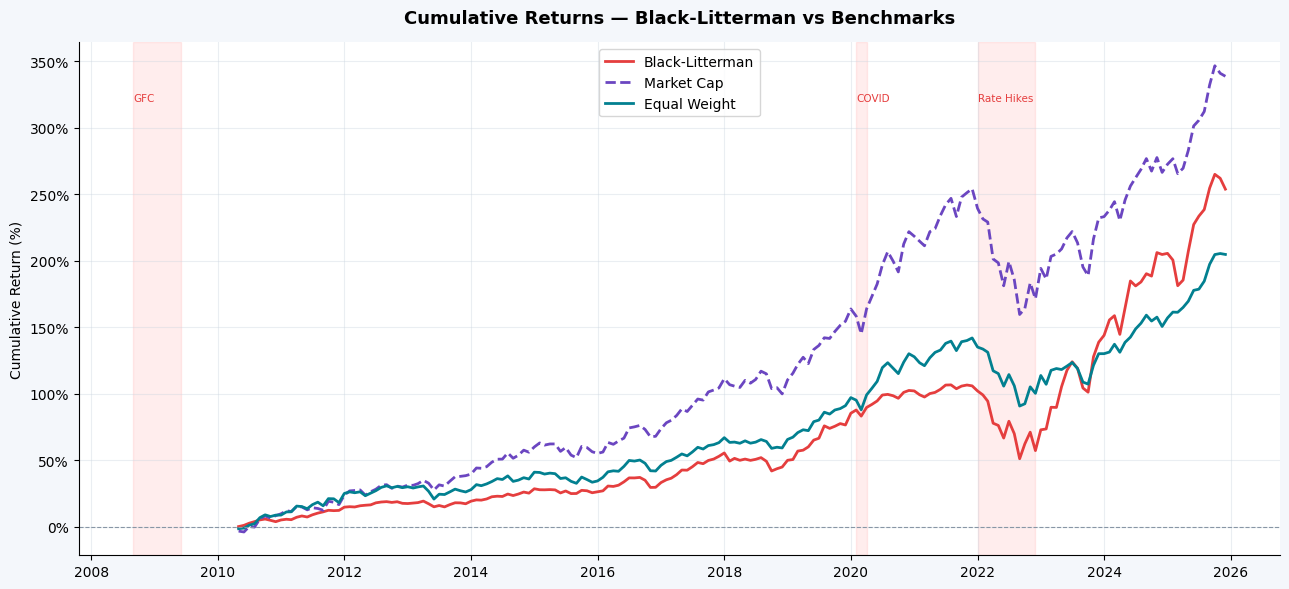

In [24]:
# ── Cell 8: Cumulative Returns ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 6))

for label, monthly_returns in all_strategies.items():
    cumulative_growth_pct = ((1 + monthly_returns).cumprod() - 1) * 100
    ax.plot(cumulative_growth_pct, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label == "Market Cap" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Returns — Black-Litterman vs Benchmarks",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

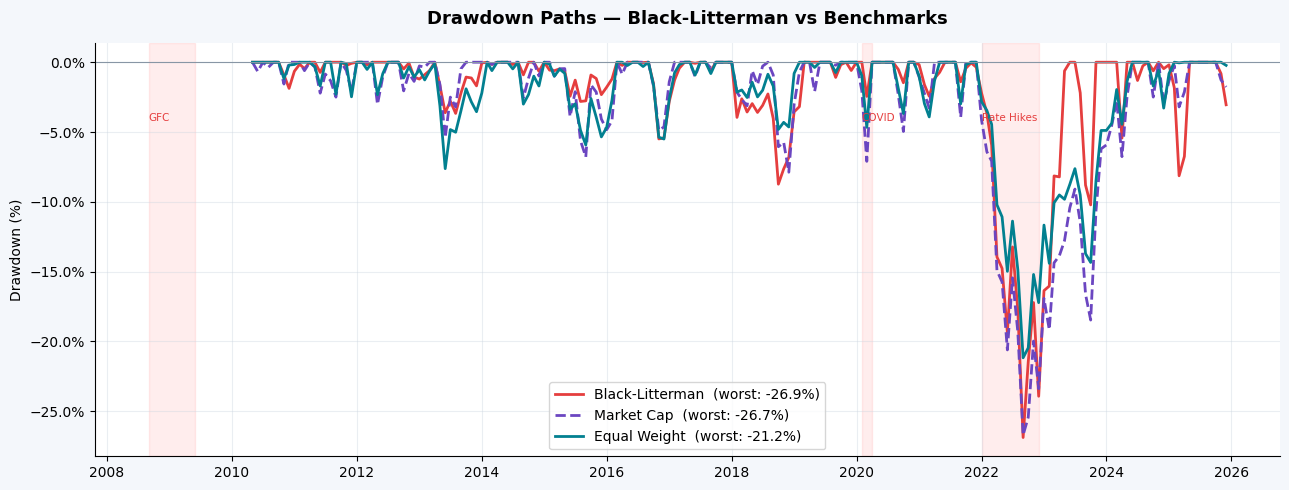

In [25]:
# ── Cell 9: Drawdown Paths ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_pct     = ((cumulative_value - rolling_peak) / rolling_peak) * 100
    ax.plot(drawdown_pct,
            label=f"{label}  (worst: {drawdown_pct.min():.1f}%)",
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label == "Market Cap" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_min = ax.get_ylim()[0]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_min * 0.15,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — Black-Litterman vs Benchmarks",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

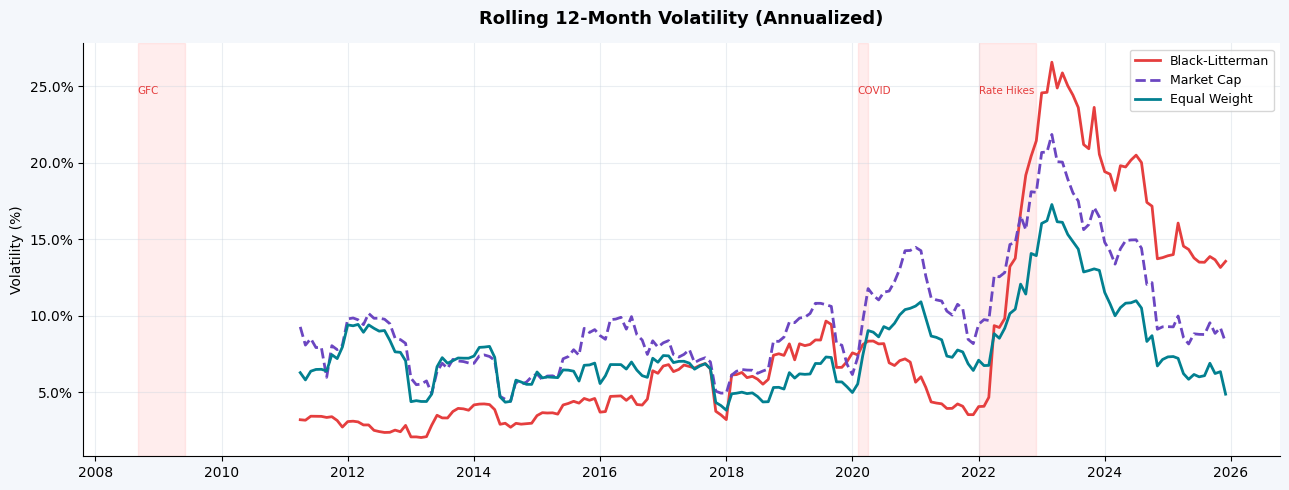

In [26]:
# ── Cell 10: Rolling 12-Month Volatility ──────────────────────────────────────

rolling_window_months = 12

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    rolling_vol = (
        monthly_returns.rolling(rolling_window_months).std() * np.sqrt(12) * 100
    )
    ax.plot(rolling_vol, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label == "Market Cap" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {rolling_window_months}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
# ── Cell 11: Recovery Dynamics ────────────────────────────────────────────────

def months_to_recover(monthly_returns, crisis_start, crisis_end):
    cumulative_value  = (1 + monthly_returns).cumprod()
    pre_crisis_values = cumulative_value.loc[:crisis_start]
    if pre_crisis_values.empty:
        return None
    pre_crisis_peak   = pre_crisis_values.max()
    crisis_values     = cumulative_value.loc[crisis_start:crisis_end]
    if crisis_values.empty:
        return None
    trough_date       = crisis_values.idxmin()
    post_trough       = cumulative_value.loc[trough_date:]
    recovered_months  = post_trough[post_trough >= pre_crisis_peak]
    if recovered_months.empty:
        return None
    recovery_date     = recovered_months.index[0]
    months_elapsed    = len(cumulative_value.loc[trough_date:recovery_date]) - 1
    return months_elapsed


print("── Recovery Time (months from trough back to pre-crisis peak) ──\n")
header = f"{'Crisis':<16}" + "".join(f"{label:>24}" for label in all_strategies)
print(header)
print("-" * len(header))

for crisis_start, crisis_end, crisis_label in CRISES:
    row = f"{crisis_label:<16}"
    for label, monthly_returns in all_strategies.items():
        months = months_to_recover(monthly_returns, crisis_start, crisis_end)
        row += f"{'Not recovered':>24}" if months is None else f"{months} months".rjust(24)
    print(row)

── Recovery Time (months from trough back to pre-crisis peak) ──

Crisis                   Black-Litterman              Market Cap            Equal Weight
----------------------------------------------------------------------------------------
GFC                        Not recovered           Not recovered           Not recovered
COVID                           1 months                1 months                1 months
Rate Hikes                      9 months               21 months               21 months


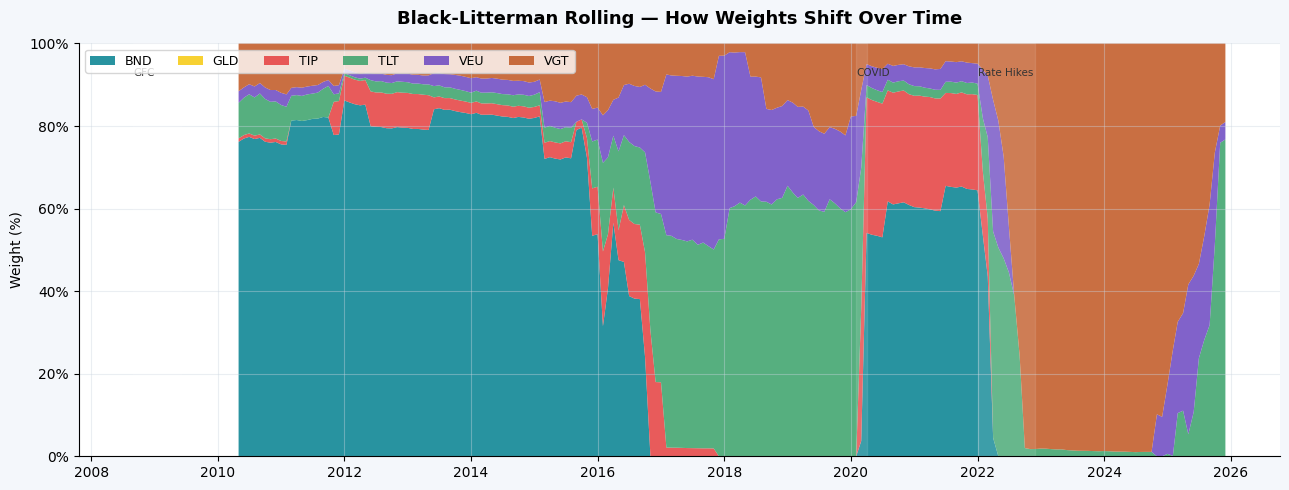

In [28]:
# ── Cell 12: Rolling Weight Evolution ────────────────────────────────────────
# Shows how Black-Litterman weights shift over time as the rolling covariance
# updates. Unlike the static market cap weights, BL weights move as the
# risk structure of the assets changes — even though the views stay fixed.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    rolling_weights_df.index,
    [rolling_weights_df[asset] * 100 for asset in assets],
    labels=assets, colors=asset_colors, alpha=0.85
)

for crisis_start, crisis_end, _ in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.10, color="white", zorder=2)
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), 92,
            crisis_label, fontsize=7.5, color="#333")

ax.set_title("Black-Litterman Rolling — How Weights Shift Over Time",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Weight (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, ncol=num_assets, loc="upper left")
plt.tight_layout()
plt.show()

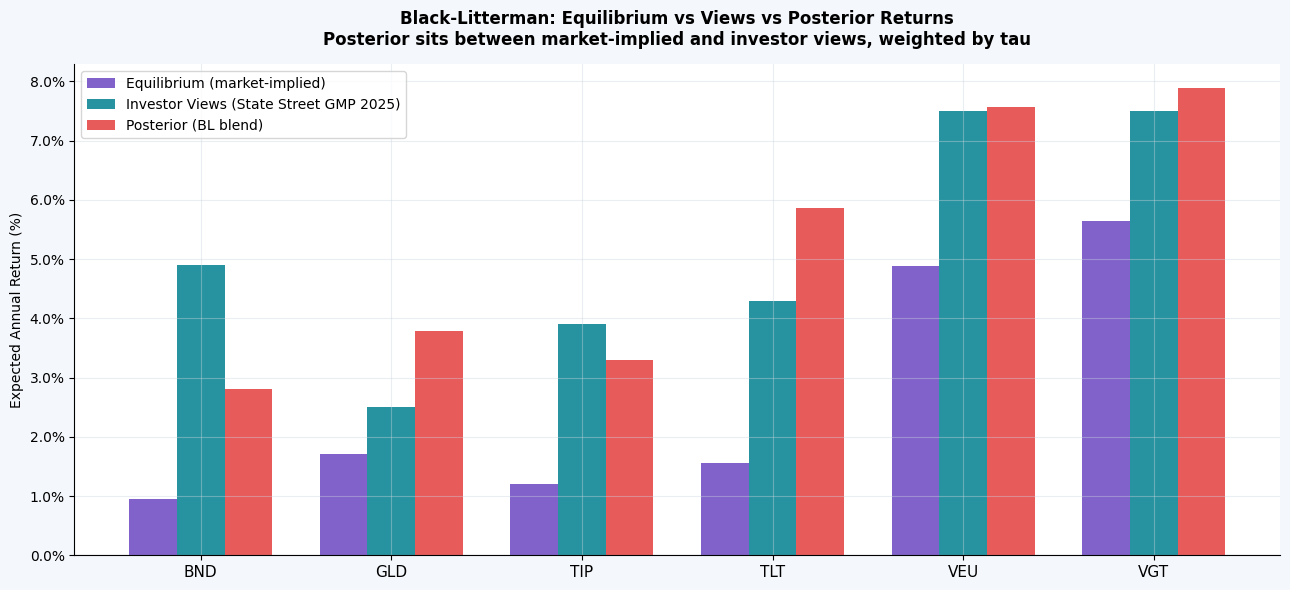

In [29]:
# ── Cell 13: Equilibrium vs Views vs Posterior (Static Visualization) ─────────
# Visual explanation of the Black-Litterman blend.
# Shows how the posterior returns sit between the market equilibrium
# and the investor views for each asset.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]
x_positions  = np.arange(num_assets)
bar_width    = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x_positions - bar_width, static_equilibrium_returns * 100,
       width=bar_width, label="Equilibrium (market-implied)",
       color="#6B46C1", alpha=0.85)
ax.bar(x_positions,             investor_view_array * 100,
       width=bar_width, label="Investor Views (State Street GMP 2025)",
       color="#028090", alpha=0.85)
ax.bar(x_positions + bar_width, static_posterior_returns * 100,
       width=bar_width, label="Posterior (BL blend)",
       color="#E53E3E", alpha=0.85)

ax.set_xticks(x_positions)
ax.set_xticklabels(assets, fontsize=11)
ax.set_ylabel("Expected Annual Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title(
    "Black-Litterman: Equilibrium vs Views vs Posterior Returns\n"
    "Posterior sits between market-implied and investor views, weighted by tau",
    fontsize=12, fontweight="bold", pad=14
)
ax.legend(fontsize=10)
ax.axhline(0, color="#8896A5", linewidth=0.8)
plt.tight_layout()
plt.show()

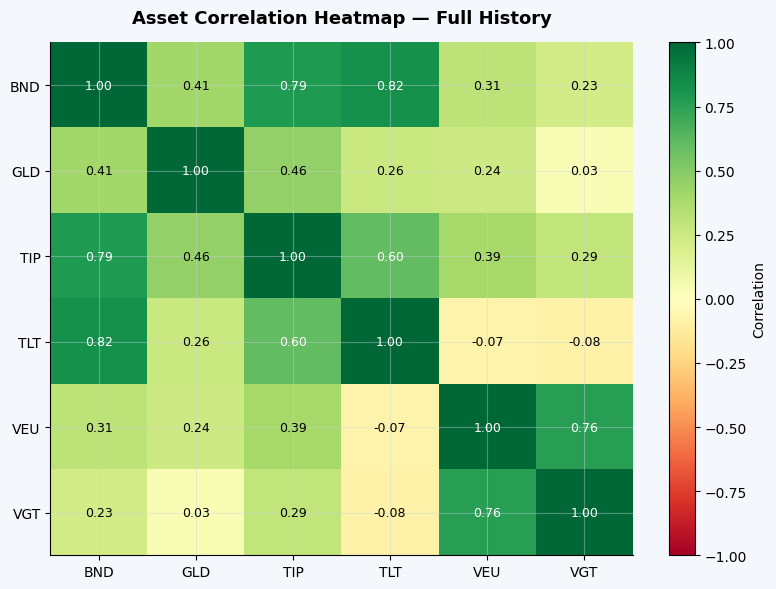

In [30]:
# ── Cell 14: Correlation Heatmap ──────────────────────────────────────────────

correlation_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
colormap = plt.cm.RdYlGn
heatmap  = ax.imshow(correlation_matrix, cmap=colormap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(heatmap, ax=ax, label="Correlation")

ax.set_xticks(range(num_assets))
ax.set_yticks(range(num_assets))
ax.set_xticklabels(assets, fontsize=10)
ax.set_yticklabels(assets, fontsize=10)

for row_index in range(num_assets):
    for col_index in range(num_assets):
        correlation_value = correlation_matrix.iloc[row_index, col_index]
        text_color        = "white" if abs(correlation_value) > 0.6 else "black"
        ax.text(col_index, row_index,
                f"{correlation_value:.2f}",
                ha="center", va="center",
                fontsize=9, color=text_color)

ax.set_title("Asset Correlation Heatmap — Full History",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()